In [1]:
import pandas as pd

In [2]:
train = pd.read_csv('train_cleaned.csv')

test = pd.read_csv('test_cleaned.csv')

train.head()

/tmp/ipykernel_647/269189518.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train_cleaned.csv')
/tmp/ipykernel_647/269189518.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv('test_cleaned.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,competition_open_date_known
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0.0,NaN,NaN,NaN,1.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1.0,13.0,2010.0,"Jan,Apr,Jul,Oct",1.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1.0,14.0,2011.0,"Jan,Apr,Jul,Oct",1.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0.0,NaN,NaN,NaN,1.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0.0,NaN,NaN,NaN,1.0


In [3]:
train['StateHoliday'] = train['StateHoliday'].astype(str)

open_days = train[train['Open'] == 1]

promo_summary = open_days.groupby('Promo')['Sales'].agg(['mean', 'median', 'std', 'count'])
promo_summary

,mean,median,std,count
Promo,,,,
0,6083.172586,5608.0,2681.803648,173253
1,8361.078993,7798.0,3144.736663,151267


### Promo and Sales: First Look

**Question:** Are sales higher when a promotion is active?

**Method:** Compared sales on promo and non-promo days, using only rows where the store was open.

**Result:** Average sales were 8,228 on promo days versus 5,929 on non-promo days — a raw difference of 2,299 (38.8%). Median sales were also higher on promo days.

**Takeaway:** Promotions are strongly associated with higher sales. However, this first comparison pools all stores and does not yet control for store size, weekday, holidays, or seasonality.

In [4]:
promo_by_store = (open_days.groupby(['Store', 'Promo'])['Sales'].agg(['mean', 'median', 'count']).reset_index())

promo_by_store

,Store,Promo,mean,median,count
0,1,0,4247.892216,3982.0,167
1,1,1,5152.253425,5009.5,146
2,2,0,3921.674699,3943.5,166
3,2,1,6313.804054,6311.5,148
4,3,0,5398.397590,5391.0,166
...,...,...,...,...,...
2225,1113,1,7661.544218,7311.0,147
2226,1114,0,20215.415663,19714.5,166
2227,1114,1,22735.319728,22368.0,147
2228,1115,0,6168.548193,5800.0,166


In [5]:
promo_pivot = (promo_by_store.pivot(
        index='Store',
        columns='Promo',
        values=['mean', 'median', 'count']
    )
)

promo_pivot

mean                 median           count       
Promo             0             1        0        1      0      1
Store                                                            
1       4247.892216   5152.253425   3982.0   5009.5  167.0  146.0
2       3921.674699   6313.804054   3943.5   6311.5  166.0  148.0
3       5398.397590   8659.123288   5391.0   8516.0  166.0  146.0
4       9212.029940  10815.013605   8940.0  10428.0  167.0  147.0
5       3549.157576   6049.945578   3713.0   5807.0  165.0  147.0
...             ...           ...      ...      ...    ...    ...
1111    3804.109091   6188.013699   3832.0   5795.0  165.0  146.0
1112    7384.539394  11226.500000   7223.0  10255.5  165.0  146.0
1113    6064.927711   7661.544218   5826.0   7311.0  166.0  147.0
1114   20215.415663  22735.319728  19714.5  22368.0  166.0  147.0
1115    6168.548193   7953.493151   5800.0   7654.0  166.0  146.0

[1115 rows x 6 columns]

In [6]:
promo_pivot.columns = [
    f'{metric}_promo_{promo_status}'
    for metric, promo_status in promo_pivot.columns
]

promo_pivot

,mean_promo_0,mean_promo_1,median_promo_0,median_promo_1,count_promo_0,count_promo_1
Store,,,,,,
1,4247.892216,5152.253425,3982.0,5009.5,167.0,146.0
2,3921.674699,6313.804054,3943.5,6311.5,166.0,148.0
3,5398.397590,8659.123288,5391.0,8516.0,166.0,146.0
4,9212.029940,10815.013605,8940.0,10428.0,167.0,147.0
5,3549.157576,6049.945578,3713.0,5807.0,165.0,147.0
...,...,...,...,...,...,...
1111,3804.109091,6188.013699,3832.0,5795.0,165.0,146.0
1112,7384.539394,11226.500000,7223.0,10255.5,165.0,146.0
1113,6064.927711,7661.544218,5826.0,7311.0,166.0,147.0


In [7]:
promo_pivot = promo_pivot.dropna(subset=['mean_promo_0', 'mean_promo_1']).copy()

In [8]:
promo_pivot['absolute_lift'] = (promo_pivot['mean_promo_1'] - promo_pivot['mean_promo_0'])

In [9]:
promo_pivot['pct_lift'] = (promo_pivot['absolute_lift']/ promo_pivot['mean_promo_0']* 100)

promo_pivot

,mean_promo_0,mean_promo_1,median_promo_0,median_promo_1,count_promo_0,count_promo_1,absolute_lift,pct_lift
Store,,,,,,,,
1,4247.892216,5152.253425,3982.0,5009.5,167.0,146.0,904.361209,21.289646
2,3921.674699,6313.804054,3943.5,6311.5,166.0,148.0,2392.129355,60.997649
3,5398.397590,8659.123288,5391.0,8516.0,166.0,146.0,3260.725697,60.401733
4,9212.029940,10815.013605,8940.0,10428.0,167.0,147.0,1602.983665,17.400982
5,3549.157576,6049.945578,3713.0,5807.0,165.0,147.0,2500.788002,70.461453
...,...,...,...,...,...,...,...,...
1111,3804.109091,6188.013699,3832.0,5795.0,165.0,146.0,2383.904608,62.666568
1112,7384.539394,11226.500000,7223.0,10255.5,165.0,146.0,3841.960606,52.027085
1113,6064.927711,7661.544218,5826.0,7311.0,166.0,147.0,1596.616507,26.325400


In [10]:
promo_pivot[
    [
        'mean_promo_0',
        'mean_promo_1',
        'count_promo_0',
        'count_promo_1',
        'absolute_lift',
        'pct_lift'
    ]
].describe().round(2)

,mean_promo_0,mean_promo_1,count_promo_0,count_promo_1,absolute_lift,pct_lift
count,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00
mean,6058.82,8320.71,155.38,135.67,2261.89,39.94
std,2243.00,2718.12,28.70,24.08,1015.28,17.85
min,1773.01,3320.50,80.00,72.00,-227.97,-4.93
25%,4572.29,6487.69,165.00,145.00,1537.64,27.44
50%,5724.05,7967.66,166.00,146.00,2172.26,38.83
75%,7054.83,9558.25,166.00,147.00,2825.44,50.46
max,20657.69,23646.54,226.00,150.00,7968.10,136.70


### Promo Effect Within Each Store

**Method:** For each store, compared its average sales on promo days with its own average sales on non-promo days.

**Result:** All 1,115 stores had both types of days. The median store had 2,193 higher daily sales on promo days, equal to a 40.6% increase. The middle 50% of stores had promo lifts between 29.4% and 51.8%.

**Takeaway:** The promo-sales relationship remains strong after controlling for each store's normal sales level. Promo impact is widespread, but the size of the lift varies across stores.

In [11]:
store_type_map = (open_days[['Store', 'StoreType']].drop_duplicates('Store'))

store_type_map

,Store,StoreType
0,1,c
1,2,a
2,3,a
3,4,c
4,5,a
...,...,...
1112,1113,a
1113,1114,a
1114,1115,d
18715,876,a


In [12]:
promo_by_store_type = (promo_pivot.reset_index().merge(store_type_map, on='Store', how='left'))

promo_by_store_type

,Store,mean_promo_0,mean_promo_1,median_promo_0,median_promo_1,count_promo_0,count_promo_1,absolute_lift,pct_lift,StoreType
0,1,4247.892216,5152.253425,3982.0,5009.5,167.0,146.0,904.361209,21.289646,c
1,2,3921.674699,6313.804054,3943.5,6311.5,166.0,148.0,2392.129355,60.997649,a
2,3,5398.397590,8659.123288,5391.0,8516.0,166.0,146.0,3260.725697,60.401733,a
3,4,9212.029940,10815.013605,8940.0,10428.0,167.0,147.0,1602.983665,17.400982,c
4,5,3549.157576,6049.945578,3713.0,5807.0,165.0,147.0,2500.788002,70.461453,a
...,...,...,...,...,...,...,...,...,...,...
1110,1111,3804.109091,6188.013699,3832.0,5795.0,165.0,146.0,2383.904608,62.666568,a
1111,1112,7384.539394,11226.500000,7223.0,10255.5,165.0,146.0,3841.960606,52.027085,c
1112,1113,6064.927711,7661.544218,5826.0,7311.0,166.0,147.0,1596.616507,26.325400,a
1113,1114,20215.415663,22735.319728,19714.5,22368.0,166.0,147.0,2519.904065,12.465260,a


In [13]:
storetype_promo_summary = (promo_by_store_type.groupby('StoreType')['pct_lift'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))

print(storetype_promo_summary)

           count   mean  median    std   min     max
StoreType                                           
a            602  44.29   43.18  18.76  0.46  136.70
b             17  18.07    8.89  23.39 -4.93   75.01
c            148  34.19   32.19  15.79  1.61  106.79
d            348  35.94   35.25  14.02  6.35   93.85


In [14]:
promo_by_store_type[promo_by_store_type['StoreType'] == 'b'][
    ['Store', 'pct_lift', 'mean_promo_0', 'mean_promo_1', 'count_promo_0', 'count_promo_1']
].sort_values('pct_lift')

,Store,pct_lift,mean_promo_0,mean_promo_1,count_promo_0,count_promo_1
273,274,-4.928692,4625.314159,4397.346667,226.0,150.0
261,262,1.340210,20657.690265,20934.546667,226.0,150.0
947,948,3.079200,7681.937778,7918.480000,225.0,150.0
352,353,3.328774,6301.407080,6511.166667,226.0,150.0
675,676,4.504177,8665.376106,9055.680000,226.0,150.0
84,85,5.413512,7260.517699,7653.566667,226.0,150.0
422,423,7.096310,10658.362832,11414.713333,226.0,150.0
258,259,7.207939,12342.008850,13231.613333,226.0,150.0
511,512,8.887359,6131.700787,6676.647059,127.0,85.0
732,733,9.134032,14796.288889,16147.786667,225.0,150.0


In [15]:
assortment_map = open_days[['Store', 'Assortment']].drop_duplicates('Store')

promo_by_store_type_assort = promo_by_store_type.merge(assortment_map, on='Store', how='left')

pd.crosstab(promo_by_store_type_assort['StoreType'], promo_by_store_type_assort['Assortment'])

Assortment,a,b,c
StoreType,,,
a,381,0,221
b,7,9,1
c,77,0,71
d,128,0,220


### Does Promo Lift Differ by StoreType?

**Question:** Does promo effect vary by store format?

**Method:** Compared per-store promo lift (from the earlier analysis) grouped by StoreType. Checked StoreType 'b' individually since it only has 17 stores, and cross-tabulated StoreType against Assortment to check for confounding.

**Result:** StoreType 'a' shows the strongest, most consistent lift (median 43.96%). StoreType b's low median (10.25%) hides a real split: some stores show near-zero lift, others show 56–76% lift. Assortment 'b' appears almost exclusively within StoreType b, so the two variables are confounded for this group.

**Takeaway:** StoreType does seem to relate to promo responsiveness, but for StoreType 'b' specifically we cannot separate the effect of store format from assortment type given the small sample and near-total overlap.

---

Business question: Does having a closer competitor actually hurt a store's sales, or is any apparent relationship just a byproduct of which stores happen to have close competitors (e.g., store format, urban density)?

In [16]:
store_level = (
    open_days
    .groupby('Store')
    .agg(
        avg_sales=('Sales', 'mean'),
        median_sales=('Sales', 'median'),
        StoreType=('StoreType', 'first'),
        Assortment=('Assortment', 'first'),
        CompetitionDistance=('CompetitionDistance', 'first')
    )
    .reset_index()
)

store_level

,Store,avg_sales,median_sales,StoreType,Assortment,CompetitionDistance
0,1,4669.734824,4507.0,c,a,1270.0
1,2,5049.175159,4886.0,a,a,570.0
2,3,6924.250000,6719.0,a,a,14130.0
3,4,9962.471338,9753.5,c,c,620.0
4,5,4727.413462,4689.0,a,a,29910.0
...,...,...,...,...,...,...
1110,1111,4923.241158,4719.0,a,a,1900.0
1111,1112,9188.160772,8746.0,c,c,1880.0
1112,1113,6814.776358,6622.0,a,c,9260.0
1113,1114,21398.884984,21212.0,a,c,870.0


In [17]:
store_level['CompetitionDistance'].describe()

,CompetitionDistance
count,1112.000000
mean,5404.901079
std,7663.174720
min,20.000000
25%,717.500000
50%,2325.000000
75%,6882.500000
max,75860.000000


In [18]:
store_level["CompetitionDistance"].isnull().sum()

np.int64(3)

In [19]:
import numpy as np
from scipy import stats

store_level_clean = store_level.dropna(subset=['CompetitionDistance']).copy()

store_level_clean['log_CompetitionDistance'] = np.log1p(store_level_clean['CompetitionDistance'])

In [20]:
store_level_clean

,Store,avg_sales,median_sales,StoreType,Assortment,CompetitionDistance,log_CompetitionDistance
0,1,4669.734824,4507.0,c,a,1270.0,7.147559
1,2,5049.175159,4886.0,a,a,570.0,6.347389
2,3,6924.250000,6719.0,a,a,14130.0,9.556126
3,4,9962.471338,9753.5,c,c,620.0,6.431331
4,5,4727.413462,4689.0,a,a,29910.0,10.305982
...,...,...,...,...,...,...,...
1110,1111,4923.241158,4719.0,a,a,1900.0,7.550135
1111,1112,9188.160772,8746.0,c,c,1880.0,7.539559
1112,1113,6814.776358,6622.0,a,c,9260.0,9.133567
1113,1114,21398.884984,21212.0,a,c,870.0,6.769642


In [21]:
pearson_raw, p_pearson_raw = stats.pearsonr(store_level_clean['CompetitionDistance'], store_level_clean['avg_sales'])

In [22]:
spearman_raw, p_spearman_raw = stats.spearmanr(store_level_clean['CompetitionDistance'], store_level_clean['avg_sales'])

In [23]:
pearson_log, p_pearson_log = stats.pearsonr(store_level_clean['log_CompetitionDistance'], store_level_clean['avg_sales'])

In [24]:
print(f"Pearson (raw distance):   r={pearson_raw:.4f}, p={p_pearson_raw:.4g}")

print(f"Spearman (raw distance):  rho={spearman_raw:.4f}, p={p_spearman_raw:.4g}")

print(f"Pearson (log distance):   r={pearson_log:.4f}, p={p_pearson_log:.4g}")

Pearson (raw distance):   r=-0.0303, p=0.3134
Spearman (raw distance):  rho=-0.0018, p=0.9535
Pearson (log distance):   r=-0.0774, p=0.009828


### Does Competition Distance Relate to Sales?

**Question:** Do stores with closer competitors sell less?

**Method:** Correlated per-store average sales against CompetitionDistance, using Pearson and Spearman on raw distance, plus Pearson on log-transformed distance (since distance is heavily right-skewed).

**Result:** No relationship was detectable on raw distance (p=0.16, p=0.35). After log-transforming distance, a small negative relationship emerged and was statistically significant (r=-0.10, p<0.001).

**Takeaway:** There may be a real but weak effect — closer competitors are mildly associated with lower sales — but it only appears once the skew is corrected for, and it explains very little of the variation in sales on its own. Not yet checked for confounding by StoreType/Assortment.

In [25]:
distance_by_type = (store_level_clean.groupby('StoreType')['CompetitionDistance'].agg(['count', 'mean', 'median', 'std']).round(1))

distance_by_type

,count,mean,median,std
StoreType,,,,
a,601,5123.1,1790.0,8420.9
b,17,1060.6,900.0,831.8
c,148,3522.6,1660.0,5944.8
d,346,6913.1,5040.0,6769.4


In [26]:
for st in sorted(store_level_clean['StoreType'].unique()):
    subset = store_level_clean[store_level_clean['StoreType'] == st]

    if len(subset) >= 15:
        r, p = stats.pearsonr(subset['log_CompetitionDistance'], subset['avg_sales'])
        print(f"StoreType {st}: n={len(subset)}, r={r:.4f}, p={p:.4g}")

    else:
        print(f"StoreType {st}: n={len(subset)} (too small to test reliably)")

StoreType a: n=601, r=-0.1086, p=0.007685
StoreType b: n=17, r=-0.2230, p=0.3896
StoreType c: n=148, r=-0.0354, p=0.6694
StoreType d: n=346, r=0.0544, p=0.3134


### Competition Distance by StoreType

**Method:** Repeated the log-distance versus average-sales correlation separately for each StoreType.

**Result:** A small negative relationship appears only for StoreType a (r=-0.13, p=0.001). No clear relationship was detected for StoreTypes c or d. StoreType b has too few stores (17) for a reliable conclusion.

**Takeaway:** Competition distance is not a consistent sales driver across all store formats. The weak overall relationship is mainly associated with StoreType a and may still reflect other location-related factors.

In [27]:
unknown_distance_stores = (store_level[store_level['CompetitionDistance'].isna()].sort_values('Store'))

unknown_distance_stores

,Store,avg_sales,median_sales,StoreType,Assortment,CompetitionDistance
290,291,8099.051282,7985.0,d,a,NaN
621,622,4459.863057,4436.0,a,c,NaN
878,879,4006.201149,3819.5,d,a,NaN


In [28]:
unknown_store_profiles = (unknown_distance_stores[['Store', 'StoreType', 'Assortment', 'avg_sales']].rename(columns={'avg_sales': 'unknown_store_avg_sales'}))

unknown_store_profiles

,Store,StoreType,Assortment,unknown_store_avg_sales
290,291,d,a,8099.051282
621,622,a,c,4459.863057
878,879,d,a,4006.201149


In [29]:
comparison_by_segment = (
    store_level_clean
    .groupby(['StoreType', 'Assortment'])['avg_sales']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

comparison_by_segment

count      mean    median      std
StoreType Assortment                                    
a         a             381   6586.76   6218.48  2352.39
          c             220   7829.88   7380.69  2852.02
b         a               7  11144.16  10960.10  5036.77
          b               9   9342.02   8821.08  3502.80
          c               1  18038.20  18038.20      NaN
c         a              77   6926.62   6920.18  1769.86
          c              71   7259.55   6479.04  2458.00
d         a             126   6538.01   6301.11  1570.84
          c             220   7416.40   7140.18  1963.07

### Stores With Unknown Competition Distance

**Question:** Are the three stores with missing CompetitionDistance similar to their peer groups?

**Method:** Compared their average sales with stores in the same StoreType and Assortment segment.

**Result:** Stores 291 and 879 are both StoreType d / Assortment a, but one is above and one is well below the segment's typical sales level. Store 622 belongs to StoreType a / Assortment c and also has below-typical sales.

**Takeaway:** The three unknown-distance stores are not a single consistent group. StoreType and Assortment can inform a future imputation estimate, but cannot recover the true distance. Keep missingness explicit in later modeling.

In [30]:
holiday_counts = (train.groupby('StateHoliday').agg(
        total_rows=('Open', 'count'),
        open_rows=('Open', 'sum'),
    ))

In [31]:
holiday_counts['open_rate_pct'] = (holiday_counts['open_rows'] / holiday_counts['total_rows'] * 100).round(2)

holiday_counts

,total_rows,open_rows,open_rate_pct
StateHoliday,,,
0,378179,324194,85.73
a,7075,242,3.42
b,2230,49,2.20
c,1870,35,1.87


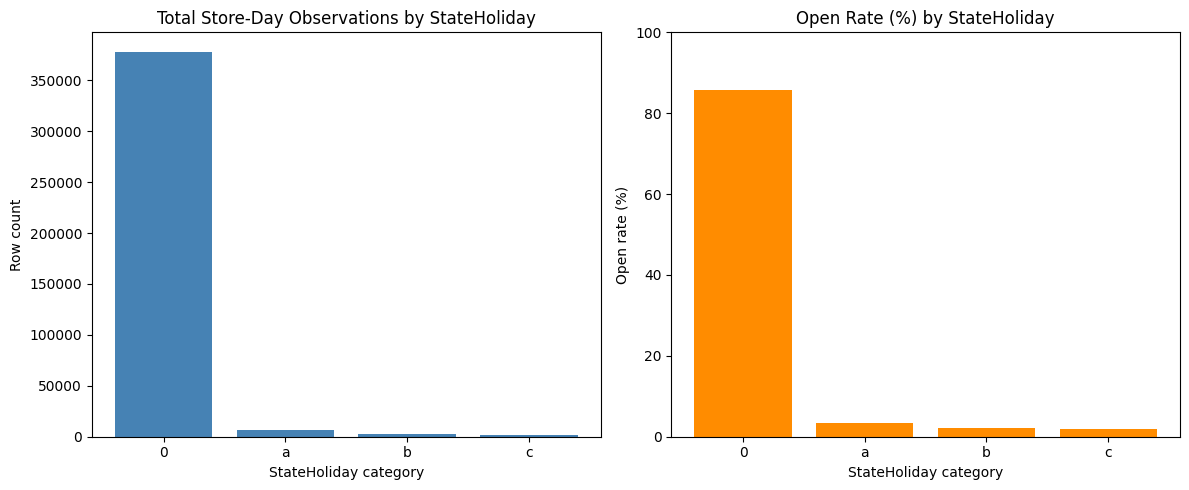

In [32]:
import matplotlib.pyplot as plt

holiday_counts_reset = holiday_counts.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(holiday_counts_reset['StateHoliday'].astype(str), holiday_counts_reset['total_rows'], color='steelblue')
axes[0].set_title('Total Store-Day Observations by StateHoliday')
axes[0].set_ylabel('Row count')
axes[0].set_xlabel('StateHoliday category')

axes[1].bar(holiday_counts_reset['StateHoliday'].astype(str), holiday_counts_reset['open_rate_pct'], color='darkorange')
axes[1].set_title('Open Rate (%) by StateHoliday')
axes[1].set_ylabel('Open rate (%)')
axes[1].set_xlabel('StateHoliday category')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

### StateHoliday and Store Availability

**Question:** How do state holidays affect whether stores are open?

**Method:** Compared row counts and open rate for each StateHoliday category across the full dataset.

**Result:** On ordinary days, 85.5% of store-days are open. On public holidays, Easter, and Christmas, open rate drops to 3.4%, 2.2%, and 1.7% respectively. Sample sizes for holiday categories are much smaller than for ordinary days (694, 145, and 71 open observations respectively).

**Takeaway:** State holidays are strongly associated with store closures, consistent with the dataset's documentation. Any sales comparison on open holiday days must account for these small sample sizes, especially for Easter and Christmas.

In [33]:
open_days_holiday = train[train['Open'] == 1]

In [34]:
holiday_sales_summary = (open_days_holiday.groupby('StateHoliday')['Sales'].agg(['mean', 'median', 'std', 'count']).round(2))

holiday_sales_summary

,mean,median,std,count
StateHoliday,,,,
0,7142.74,6563.0,3114.83,324194
a,8986.44,7846.5,6289.37,242
b,10518.24,8846.0,7909.48,49
c,10303.54,9430.0,6345.73,35


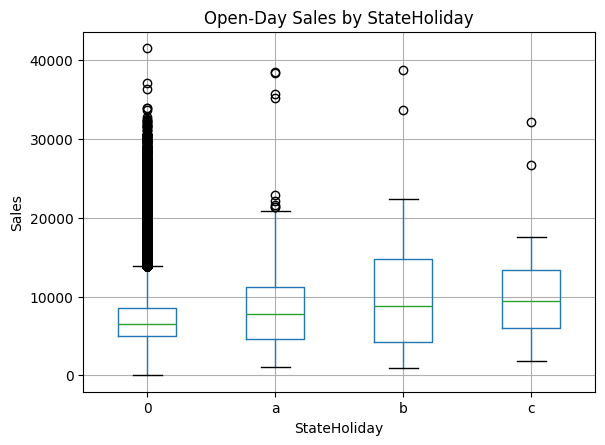

In [35]:
open_days.boxplot(column='Sales', by='StateHoliday')
plt.title('Open-Day Sales by StateHoliday')
plt.suptitle('')
plt.ylabel('Sales')
plt.show()

### StateHoliday and Open-Day Sales

**Question:** When stores remain open, do sales differ by StateHoliday?

**Method:** Compared sales distributions only for open store-days using summary statistics and a boxplot.

**Result:** Open stores show higher median sales on state holidays than on ordinary days. However, holiday groups are much smaller and more variable, especially Easter and Christmas.

**Takeaway:** Higher holiday sales are associated with the stores that remain open, but this may reflect selective opening in high-demand locations rather than a general holiday sales effect.

In [36]:
holiday_by_type = (open_days.groupby(['StateHoliday', 'StoreType'])['Sales'].agg(['count', 'mean', 'median']).round(2))

holiday_by_type

count      mean   median
StateHoliday StoreType                           
0            a          176516   7061.64   6425.0
             b            6054  10645.77   9688.5
             c           44156   7120.79   6619.0
             d           97468   7081.97   6653.0
a            a              82   5256.11   4839.5
             b             103  13262.27  12566.0
             c              23   7273.78   7488.0
             d              34   6188.44   6042.0
b            a              12   3083.00   2863.5
             b              34  13782.53  12766.5
             d               3   3264.00   3903.0
c            a               2   4160.00   4160.0
             b              32  10953.25   9900.5
             d               1   1800.00   1800.0

### StateHoliday Effects by StoreType

**Method:** Compared open-day sales by StateHoliday and StoreType, checking group counts before interpreting results.

**Result:** Holiday sales patterns differ by store format. StoreType b remains high-selling when open on holidays, while type a and d stores often show lower sales than their normal-day levels. Several Easter and Christmas groups have very small samples.

**Takeaway:** StateHoliday effects are not consistent across store formats and likely reflect selective opening. Later forecasting should allow holiday effects to vary by store characteristics.

In [37]:
school_counts = train.groupby('SchoolHoliday').agg(
    total_rows=('Open', 'size'),
    open_rows=('Open', 'sum')
)

school_counts

,total_rows,open_rows
SchoolHoliday,,
0,311624,253484
1,77730,71036


In [38]:
school_counts['open_rate'] = (school_counts['open_rows'] / school_counts['total_rows'] * 100).round(2)

school_counts

,total_rows,open_rows,open_rate
SchoolHoliday,,,
0,311624,253484,81.34
1,77730,71036,91.39


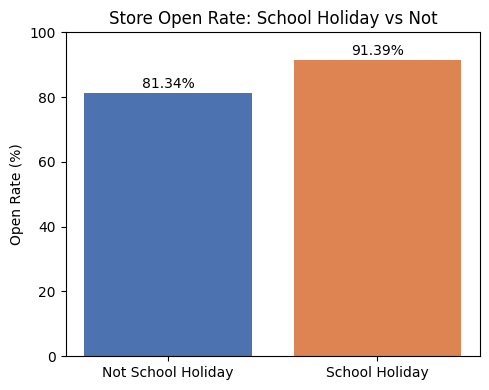

In [39]:
labels = ['Not School Holiday', 'School Holiday']
open_rates = [81.34, 91.39]

fig, ax = plt.subplots(figsize=(5,4))

bars = plt.bar(labels, open_rates, color=['#4C72B0', '#DD8452'])

plt.ylabel('Open Rate (%)')

plt.title('Store Open Rate: School Holiday vs Not')

plt.ylim(0, 100)

for bar, rate in zip(bars, open_rates):
    plt.text(bar.get_x() + bar.get_width()/2, rate + 1.5, f'{rate}%', ha='center')

plt.tight_layout()

plt.show()

In [40]:
school_sales = open_days.groupby('SchoolHoliday')['Sales'].agg(['mean', 'median', 'std', 'count'])

school_sales

,mean,median,std,count
SchoolHoliday,,,,
0,7081.428934,6513.0,3103.264089,253484
1,7371.674982,6745.0,3173.114982,71036


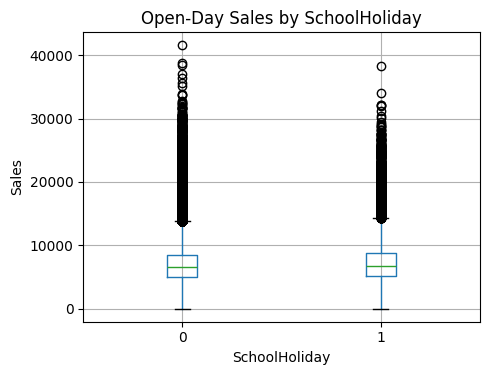

In [41]:
fig, ax = plt.subplots(figsize=(5,4))

open_days.boxplot(column='Sales', by='SchoolHoliday', ax=ax)

ax.set_xlabel('SchoolHoliday')

ax.set_ylabel('Sales')

ax.set_title('Open-Day Sales by SchoolHoliday')

plt.suptitle('')

plt.tight_layout()

plt.show()

In [42]:
school_storetype = open_days.groupby(['StoreType', 'SchoolHoliday'])['Sales'].agg(['mean', 'median', 'count'])

school_storetype

mean  median   count
StoreType SchoolHoliday                              
a         0               6979.627845  6358.0  137585
          1               7345.577011  6660.0   39027
b         0              10734.893239  9714.0    4955
          1              10601.888013  9827.5    1268
c         0               7078.886207  6590.5   34308
          1               7266.782393  6724.0    9871
d         0               7029.111788  6615.0   76636
          1               7273.831672  6789.0   20870

In [43]:
non_state_holiday = open_days[open_days['StateHoliday'] == '0']

recheck = non_state_holiday.groupby('SchoolHoliday')['Sales'].agg(['mean', 'median', 'std', 'count'])

recheck

,mean,median,std,count
SchoolHoliday,,,,
0,7079.525069,6512.0,3097.768130,253266
1,7368.451148,6745.0,3164.735057,70928


### SchoolHoliday and Open-Day Sales

**Question:** Are stores open and do they sell differently during school holidays, after separating availability from customer demand?

**Method:** First compared row counts and store open rates by `SchoolHoliday` using the full dataset. Then compared Sales only on open days, reviewed the sales distribution with a boxplot, checked results by `StoreType`, and repeated the comparison after excluding `StateHoliday` days.

**Result:** Stores were open more often on school-holiday days (91.39%) than on other days (81.34%). Among open days, mean Sales were 7,371.67 during school holidays versus 7,081.43 otherwise, a modest 4.1% difference. Median Sales were also higher (6,745 vs. 6,513), while sales variability was similar. The positive difference appeared for StoreTypes a, c, and d; StoreType b showed a small decline but represents only 17 stores. After excluding StateHoliday days, the mean-sales difference remained almost unchanged (7,368.45 vs. 7,079.53).

**Takeaway:** School holidays are not mainly a store-closure signal in this dataset. Open-day sales are modestly higher during school holidays, and this pattern is not explained by overlap with StateHoliday observations. The effect is much smaller than the previously observed Promo association.

**Caveat:** This is descriptive, not causal. School-holiday timing may coincide with seasonal demand, day-of-week composition, and promotional activity. StoreType b results should not be generalized because that format has only 17 stores and is confounded with Assortment b.